# Hierarchical ReLU-LoRA vs Baselines — OLMoE Conflict-Scaling Grid

**Thesis Methodology: Multi-Domain Conflict Experiment**

**Three-way comparison:**
1. **Standard LoRA** — Base adapters only, no dynamic expansion
2. **DR-LoRA** — Dynamic rank growth with saliency-based allocation
3. **Hierarchical ReLU-LoRA** — ReLU-gated sub-adapter spawning (thesis method)

**Conflict-Scaling Grid (Runs A → B → C):**
- **Run A**: 100% Code (baseline, no conflict)
- **Run B**: 80% Code + 20% Medical (moderate conflict)
- **Run C**: 50% Code + 50% Medical (severe conflict)

**Model:** allenai/OLMoE-1B-7B-0924
- 16 layers, 64 experts/layer, top-8 routing
- model_dim = 2048, ffn_dim = 1024

**Spawn Trigger:** ConflictSaturationMonitor
- Fires when BOTH hold for `window` consecutive steps:
  1. Plateau: rank importance slope < tau_plateau
  2. Conflict: |ema_medical - ema_code| > delta_threshold

**Metrics:**
- Code Perplexity (primary — evaluated on code-only probe)
- Negative Transfer = PPL_code(Run X) - PPL_code(Run A)
- Expansion Events (spawn/growth count)
- HumanEval pass@1

## Section 1 — Install & Model Load

In [1]:
# Install (run once per session)
!pip install transformers>=4.41.0 accelerate datasets peft torch>=2.2.0 tabulate -q

In [ ]:
# Load OLMoE model
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import torch.nn as nn
import torch.nn.functional as F
import gc
import os
import math
import json
from collections import deque, defaultdict
from typing import Dict, List, Optional, Tuple

# Clear any lingering VRAM
torch.cuda.empty_cache()
gc.collect()

MODEL_ID = "allenai/OLMoE-1B-7B-0125"

# Save directory setup
if os.path.exists('/kaggle'):
    SAVE_ROOT = "/kaggle/working/hrlora_checkpoints"
    print("Detected: Kaggle")
elif os.path.exists('/content'):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        SAVE_ROOT = "/content/drive/MyDrive/hrlora_checkpoints"
    except:
        SAVE_ROOT = "/content/hrlora_checkpoints"
    print("Detected: Colab")
else:
    SAVE_ROOT = "./hrlora_checkpoints"
    print("Detected: Local")

os.makedirs(SAVE_ROOT, exist_ok=True)
print(f"Checkpoints: {SAVE_ROOT}")

print(f"\nLoading {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_olmoe = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map='auto',
    trust_remote_code=True,
)
model_olmoe.config.use_cache = False  # Required for training

print(f"\nModel loaded!")
print(f"  Layers: {model_olmoe.config.num_hidden_layers}")
print(f"  Experts: {model_olmoe.config.num_experts}")
print(f"  Top-k: {model_olmoe.config.num_experts_per_tok}")
print(f"  model_dim: {model_olmoe.config.hidden_size}")
print(f"  ffn_dim: {model_olmoe.config.intermediate_size}")
print(f"  VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Detected: Kaggle
Checkpoints: /kaggle/working/hrlora_checkpoints

Loading allenai/OLMoE-1B-7B-0924...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]


Model loaded!
  Layers: 16
  Experts: 64
  Top-k: 8
  model_dim: 2048
  ffn_dim: 1024
  VRAM: 13.84 GB


## Section 2 — Class Definitions

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# HierarchicalExpert — Base LoRA sub-adapter module
# ═══════════════════════════════════════════════════════════════════════════════

class HierarchicalExpert(nn.Module):
    """
    Low-rank LoRA sub-adapter. Computes: L(x) = (x A^T B^T) * scaling

    Key: B is zero-initialized. This guarantees that at the moment of spawn,
    the sub-adapter's contribution is exactly zero (zero-loss-spike guarantee).
    """
    def __init__(self, in_features, out_features, base_rank=16, lora_alpha=32):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = base_rank
        self.scaling = lora_alpha / base_rank

        # Standard LoRA init: A ~ N(0, 0.01), B = 0
        self.A = nn.Parameter(torch.randn(base_rank, in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(out_features, base_rank))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        A = self.A.to(x.dtype)
        B = self.B.to(x.dtype)
        return (x @ A.t() @ B.t()) * self.scaling

print("HierarchicalExpert defined.")

HierarchicalExpert defined.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# DRLoRALayer — DR-LoRA with capacity reservation and binary rank mask
# ═══════════════════════════════════════════════════════════════════════════════

class DRLoRALayer(nn.Module):
    """
    DR-LoRA Layer with Capacity Reservation

    Key Innovation: Allocate full rank space (r_max) upfront,
    but activate only a subset (r_init) initially. This avoids
    dynamic tensor resizing and optimizer state corruption.
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        r_max: int = 16,
        r_init: int = 4,
        lora_alpha: int = 16,
        lora_dropout: float = 0.0,
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.r_max = r_max
        self.r_init = r_init
        self.lora_alpha = lora_alpha

        # Allocate FULL rank space upfront
        self.lora_A = nn.Parameter(torch.zeros(r_max, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, r_max))

        self.lora_dropout = nn.Dropout(p=lora_dropout)

        # Binary rank mask: 1 = active, 0 = dormant
        self.register_buffer('rank_mask', torch.zeros(r_max, dtype=torch.bool))

        # Activate first r_init ranks
        self.rank_mask[:r_init] = True
        self.active_ranks = r_init

        self.reset_parameters()

    def reset_parameters(self):
        """Initialize LoRA weights with Kaiming initialization"""
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Masked forward pass - only active ranks contribute"""
        active_mask = self.rank_mask

        if active_mask.any():
            A_active = self.lora_A[active_mask, :]
            B_active = self.lora_B[:, active_mask]

            active_ranks = active_mask.sum().item()
            scaling = self.lora_alpha / active_ranks

            result = self.lora_dropout(x) @ A_active.T @ B_active.T
            result = result * scaling
        else:
            result = torch.zeros(*x.shape[:-1], self.out_features, device=x.device, dtype=x.dtype)

        return result

    def activate_rank(self, rank_idx: int):
        """Activate a specific rank (for rank growth)"""
        if rank_idx < self.r_max:
            self.rank_mask[rank_idx] = True
            self.active_ranks = self.rank_mask.sum().item()

    def get_active_ranks(self) -> int:
        return int(self.rank_mask.sum().item())

    def get_mask_status(self) -> str:
        mask_str = ''.join(['\u2588' if m else '\u2591' for m in self.rank_mask])
        return f"[{mask_str}] ({self.get_active_ranks()}/{self.r_max})"

print("DRLoRALayer defined.")

DRLoRALayer defined.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# ConflictSaturationMonitor — Correct implementation from working Phi-MoE notebook
# ═══════════════════════════════════════════════════════════════════════════════

class ConflictSaturationMonitor:
    """
    Fires when BOTH hold for `window` consecutive steps:
      1. Plateau: rank importance slope < tau_plateau  (LoRA stopped learning)
      2. Conflict: |ema_medical - ema_code| > delta_threshold
                   (two domains have diverged in loss — real entanglement signal)
    """
    def __init__(self, tau_plateau=1e-4, delta_threshold=1.0,
                 window=15, beta=0.9):
        self.tau_plateau      = tau_plateau
        self.delta_threshold  = delta_threshold
        self.window           = window
        self.beta             = beta

        self._ri_history: list = []
        self._ema_code    = None
        self._ema_medical = None
        self._plateau_window  = []
        self._conflict_window = []

    def update(self, lora_A, lora_B, loss_val, domain, override_ri=None):
        # ── Update domain-separated EMAs ──────────────────────────────────
        b = self.beta
        if domain == "code":
            self._ema_code = (loss_val if self._ema_code is None
                              else b * self._ema_code + (1-b) * loss_val)
        else:
            self._ema_medical = (loss_val if self._ema_medical is None
                                 else b * self._ema_medical + (1-b) * loss_val)

        # ── Rank importance ───────────────────────────────────────────────
        if override_ri is not None:
            ri = override_ri
        else:
            with torch.no_grad():
                col_norms = lora_B.detach().float().norm(dim=0)
                row_norms = lora_A.detach().float().norm(dim=1)
                ri = (col_norms * row_norms).mean().item()
        self._ri_history.append(ri)

        if len(self._ri_history) < self.window:
            return False

        # OLS slope over window
        recent = self._ri_history[-self.window:]
        x = torch.arange(len(recent), dtype=torch.float32)
        y = torch.tensor(recent, dtype=torch.float32)
        slope = ((x*y).mean() - x.mean()*y.mean()) / (x.var(unbiased=False) + 1e-12)
        plateau = abs(slope.item()) < self.tau_plateau

        # Conflict: both domains seen, and their EMAs have diverged
        if self._ema_code is not None and self._ema_medical is not None:
            conflict = abs(self._ema_medical - self._ema_code) > self.delta_threshold
        else:
            conflict = False

        self._plateau_window.append(plateau)
        self._conflict_window.append(conflict)
        if len(self._plateau_window) > self.window:
            self._plateau_window.pop(0)
            self._conflict_window.pop(0)

        if (len(self._plateau_window) == self.window
                and all(self._plateau_window)
                and all(self._conflict_window)):
            self._plateau_window.clear()
            self._conflict_window.clear()
            return True

        return False

    def reset_after_spawn(self):
        self._ri_history.clear()
        self._plateau_window.clear()
        self._conflict_window.clear()

print("ConflictSaturationMonitor defined.")

ConflictSaturationMonitor defined.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# DRLoRATracker — Tracks routing frequency and rank importance EMAs
# ═══════════════════════════════════════════════════════════════════════════════

class DRLoRATracker:
    """
    Track routing frequency (Eq. 5) and rank importance (Eq. 6-8) with EMA.
    Uses forward hooks to capture actual router softmax weights.
    """

    def __init__(
        self,
        num_layers: int,
        num_experts_per_layer: int,
        ema_beta: float = 0.9,
        device: str = "cuda",
    ):
        self.num_layers = num_layers
        self.num_experts_per_layer = num_experts_per_layer
        self.ema_beta = ema_beta
        self.device = device

        # f^(l,i): routing frequency EMA
        self.routing_frequency = torch.zeros(
            num_layers, num_experts_per_layer, device=device, dtype=torch.float32
        )
        # g^(l,i): rank importance EMA
        self.rank_importance = torch.zeros(
            num_layers, num_experts_per_layer, device=device, dtype=torch.float32
        )

        self._routing_hooks = []
        self._current_router_weights: Dict[int, torch.Tensor] = {}
        self.num_updates = 0

    def register_routing_hooks(self, model) -> int:
        """Register forward hooks on gate/router modules."""
        self._remove_routing_hooks()

        for layer_idx, layer in enumerate(model.model.layers):
            gate = None
            if hasattr(layer, "mlp"):
                gate = getattr(layer.mlp, "gate", None) or getattr(layer.mlp, "router", None)

            if gate is not None:
                hook = gate.register_forward_hook(
                    self._make_router_hook(layer_idx)
                )
                self._routing_hooks.append(hook)

        return len(self._routing_hooks)

    def _make_router_hook(self, layer_idx: int):
        def hook(module, input, output):
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output
            if logits.dim() == 3:
                logits = logits.view(-1, logits.shape[-1])
            probs = F.softmax(logits.float(), dim=-1)
            self._current_router_weights[layer_idx] = probs.detach()
        return hook

    def _remove_routing_hooks(self):
        for hook in self._routing_hooks:
            hook.remove()
        self._routing_hooks = []
        self._current_router_weights = {}

    def update_routing_frequency_from_hooks(self):
        """Update routing frequency EMA from captured router weights."""
        for layer_idx, probs in self._current_router_weights.items():
            if layer_idx >= self.num_layers:
                continue
            mean_probs = probs.mean(dim=0)
            n_exp = min(mean_probs.shape[0], self.num_experts_per_layer)

            self.routing_frequency[layer_idx, :n_exp] = (
                self.ema_beta * self.routing_frequency[layer_idx, :n_exp] +
                (1 - self.ema_beta) * mean_probs[:n_exp].to(self.device)
            )
        self._current_router_weights = {}
        self.num_updates += 1

    def compute_rank_importance(self, lora_modules: list) -> Dict[Tuple[int, int], float]:
        """Compute rank importance from gradient magnitudes."""
        importance = {}
        for info in lora_modules:
            layer_idx = info["layer"]
            expert_idx = info["expert"]
            dl = info["dr_lora"]

            if dl.lora_A.grad is None or dl.lora_B.grad is None:
                importance[(layer_idx, expert_idx)] = 0.0
                continue

            active_mask = dl.rank_mask
            if not active_mask.any():
                importance[(layer_idx, expert_idx)] = 0.0
                continue

            A_grad  = dl.lora_A.grad[active_mask]
            A_param = dl.lora_A.data[active_mask]
            B_grad  = dl.lora_B.grad[:, active_mask]
            B_param = dl.lora_B.data[:, active_mask]
            A_sensitivity = (A_grad * A_param).abs().sum(dim=1)   # (r_active,)
            B_sensitivity = (B_grad * B_param).abs().sum(dim=0)   # (r_active,)
            per_rank_scores = A_sensitivity * B_sensitivity
            importance[(layer_idx, expert_idx)] = importance.get(
                (layer_idx, expert_idx), 0.0) + per_rank_scores.mean().item()

        return importance

    def update_rank_importance(self, importance: Dict[Tuple[int, int], float]):
        """Update rank importance EMA."""
        for (layer_idx, expert_idx), g_new in importance.items():
            if layer_idx < self.num_layers and expert_idx < self.num_experts_per_layer:
                self.rank_importance[layer_idx, expert_idx] = (
                    self.ema_beta * self.rank_importance[layer_idx, expert_idx] +
                    (1 - self.ema_beta) * g_new
                )

    def get_saliency(self, layer_idx: int, expert_idx: int, current_rank: int, gamma: float = 0.5) -> float:
        """Compute saliency S = f * g / (r+1)^gamma"""
        f = self.routing_frequency[layer_idx, expert_idx].item()
        g = self.rank_importance[layer_idx, expert_idx].item()
        return (f * g) / ((current_rank + 1) ** gamma)

print("DRLoRATracker defined.")

DRLoRATracker defined.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# DRLoRAGrowthSchedule — Manages rank growth timing and quotas
# ═══════════════════════════════════════════════════════════════════════════════

class DRLoRAGrowthSchedule:
    """
    DR-LoRA Growth Scheduling System

    Controls: when ranks grow, how many per event, which experts get them.
    """

    def __init__(
        self,
        total_steps: int,
        warmup_steps: int,
        growth_interval: int,
        r_init: int,
        r_target: int,
        r_max: int,
        num_experts_per_layer: int,
        num_layers: int,
        end_buffer_steps: int = 100,
    ):
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.growth_interval = growth_interval
        self.r_init = r_init
        self.r_target = r_target
        self.r_max = r_max
        self.num_experts_per_layer = num_experts_per_layer
        self.num_layers = num_layers
        self.end_buffer_steps = end_buffer_steps

        # Compute schedule
        effective_end = total_steps - end_buffer_steps
        growth_duration = max(1, effective_end - warmup_steps)
        self.num_growth_events = max(1, growth_duration // growth_interval)

        # Total ranks to add across all experts
        ranks_per_expert = r_target - r_init
        total_experts = num_experts_per_layer * num_layers
        self.total_ranks_to_add = ranks_per_expert * total_experts

        # Quota per event
        self.quota_per_event = max(1, self.total_ranks_to_add // self.num_growth_events)

        # Track growth events
        self.growth_event_steps = [
            warmup_steps + (i + 1) * growth_interval
            for i in range(self.num_growth_events)
            if warmup_steps + (i + 1) * growth_interval < effective_end
        ]

    def can_grow_at_step(self, step: int) -> bool:
        return step in self.growth_event_steps

    def get_event_index(self, step: int) -> int:
        if step in self.growth_event_steps:
            return self.growth_event_steps.index(step)
        return -1

    def get_rank_quota(self, event_idx: int = None) -> int:
        return self.quota_per_event

print("DRLoRAGrowthSchedule defined.")

DRLoRAGrowthSchedule defined.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# perform_rank_growth — Algorithm 1 lines 9-14
# ═══════════════════════════════════════════════════════════════════════════════

def perform_rank_growth(
    tracker: DRLoRATracker,
    schedule: DRLoRAGrowthSchedule,
    lora_modules: list,
    current_step: int,
    r_init: int,
    r_max: int,
    p_grow: float = 0.5,
    gamma: float = 0.5,
    verbose: bool = False,
) -> dict:
    """
    Periodic rank growth based on saliency.

    1. Compute saliency S = f * g / (r+1)^gamma
    2. Sort experts by saliency (descending)
    3. Greedy allocation with quota Q
    4. Activate dormant rank slots
    """
    if not schedule.can_grow_at_step(current_step):
        return {"grew": False}

    Q_per_layer = schedule.get_rank_quota()
    r_free = r_max - r_init
    max_per_expert = max(1, math.floor(r_free * p_grow))

    total_new_ranks = 0
    num_experts_grown = 0
    expert_growth = {}

    # Group by layer
    by_layer = defaultdict(list)
    for info in lora_modules:
        by_layer[info["layer"]].append(info)

    for layer_idx, experts in by_layer.items():
        # Compute saliency for each expert
        saliencies = []
        for info in experts:
            dl = info["dr_lora"]
            current_rank = dl.get_active_ranks()
            sal = tracker.get_saliency(layer_idx, info["expert"], current_rank, gamma)
            saliencies.append((sal, info))

        # Sort by saliency descending
        saliencies.sort(key=lambda x: x[0], reverse=True)

        # Allocate ranks
        remaining_quota = Q_per_layer
        for sal, info in saliencies:
            if remaining_quota <= 0:
                break

            dl = info["dr_lora"]
            current_rank = dl.get_active_ranks()
            free_slots = r_max - current_rank

            if free_slots <= 0:
                continue

            n_grow = min(max_per_expert, remaining_quota, free_slots)

            # Activate new ranks
            for _ in range(n_grow):
                next_rank = dl.get_active_ranks()
                if next_rank < r_max:
                    dl.activate_rank(next_rank)

            actual_grown = dl.get_active_ranks() - current_rank
            if actual_grown > 0:
                expert_growth[(layer_idx, info["expert"])] = actual_grown
                total_new_ranks += actual_grown
                num_experts_grown += 1
                remaining_quota -= actual_grown

                # Reset rank importance after growth
                tracker.rank_importance[layer_idx, info["expert"]] = 0.0

    return {
        "grew": total_new_ranks > 0,
        "total_new_ranks": total_new_ranks,
        "num_experts_grown": num_experts_grown,
        "expert_growth": expert_growth,
    }

print("perform_rank_growth defined.")

perform_rank_growth defined.


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# LoRAOLMoEExperts — Standard LoRA (no spawning, no rank growth)
# ═══════════════════════════════════════════════════════════════════════════════

class LoRAOLMoEExperts(nn.Module):
    """
    Standard LoRA wrapper for OLMoE experts.
    Fixed-rank base adapters only - no dynamic expansion.
    This is the baseline for comparison.
    """

    def __init__(self, original_experts, base_rank: int = 16, lora_alpha: int = 32):
        super().__init__()
        self.original = original_experts

        for p in self.original.parameters():
            p.requires_grad = False

        self.num_experts, self.out_f, self.in_f = self.original.down_proj.shape
        self.dtype = self.original.down_proj.dtype
        self.lora_dim = self.out_f

        dev = self.original.down_proj.device
        dtype = self.original.down_proj.dtype

        self.base_loras = nn.ModuleList([
            HierarchicalExpert(
                in_features=self.lora_dim,
                out_features=self.lora_dim,
                base_rank=base_rank,
                lora_alpha=lora_alpha,
            ).to(dev).to(dtype)
            for _ in range(self.num_experts)
        ])

        print(f"OLMoE expert dims: down_proj={self.original.down_proj.shape}")
        print(f"  → num_experts={self.num_experts}, out_f={self.out_f}, in_f={self.in_f}")
        print(f"  → lora_dim set to {self.lora_dim} (should equal hidden_size=2048)")

    @property
    def device(self) -> torch.device:
        return self.original.down_proj.device

    def forward(self, hidden_states, router_top_k_indices, router_top_k_weights):
      orig_out = self.original.forward(hidden_states, router_top_k_indices, router_top_k_weights)
      correction = torch.zeros_like(orig_out)

      for k in range(self.num_experts):
        mask = (router_top_k_indices == k)          # [T, top_k]
        if not mask.any():
            continue

        eff_w = (router_top_k_weights * mask.float()).sum(dim=1)  # [T]
        token_mask = eff_w > 0
        if not token_mask.any():
            continue

        x_k = hidden_states[token_mask]             # only routed tokens
        lora_out = self.base_loras[k](x_k)          # adapter sees only its tokens
        correction[token_mask] += eff_w[token_mask].unsqueeze(-1) * lora_out

      return (orig_out + correction).to(hidden_states.dtype)

print("LoRAOLMoEExperts defined.")

LoRAOLMoEExperts defined.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# DRLoRAOLMoEExperts — DR-LoRA with saliency-based rank growth
# ═══════════════════════════════════════════════════════════════════════════════

class DRLoRAOLMoEExperts(nn.Module):
    """
    DR-LoRA wrapper for OLMoE experts.
    Uses capacity reservation with binary rank mask for dynamic rank growth.
    """

    def __init__(self, original_experts, r_max: int = 16, r_init: int = 4, lora_alpha: int = 16):
        super().__init__()
        self.original = original_experts

        for p in self.original.parameters():
            p.requires_grad = False

        self.num_experts, self.out_f, self.in_f = self.original.down_proj.shape
        self.dtype = self.original.down_proj.dtype

        self.r_max = r_max
        self.r_init = r_init

        dev = self.original.down_proj.device

        self.dr_loras = nn.ModuleList([
            DRLoRALayer(
                in_features=self.out_f,
                out_features=self.out_f,
                r_max=r_max,
                r_init=r_init,
                lora_alpha=lora_alpha,
                lora_dropout=0.0,
            ).to(device=dev, dtype=self.dtype)
            for _ in range(self.num_experts)
        ])

    @property
    def device(self):
        return self.original.down_proj.device

    def get_lora_modules_list(self, layer_idx):
        """Returns list compatible with DRLoRATracker and perform_rank_growth."""
        return [
            {
                "layer": layer_idx,
                "expert": k,
                "dr_lora": self.dr_loras[k],
                "module": "packed_lora",
            }
            for k in range(self.num_experts)
        ]

    def forward(self, hidden_states, router_top_k_indices, router_top_k_weights):
        orig_out = self.original.forward(hidden_states, router_top_k_indices, router_top_k_weights)
        correction = torch.zeros_like(orig_out)

        T, top_k = router_top_k_indices.shape

        for k in range(self.num_experts):
            mask = (router_top_k_indices == k)
            if not mask.any():
                continue

            eff_w = (router_top_k_weights * mask.float()).sum(dim=1)
            active = eff_w.abs() > 1e-6
            if not active.any():
                continue

            x_k = hidden_states[active]
            lora_out = self.dr_loras[k](x_k)
            correction[active] += eff_w[active].unsqueeze(1) * lora_out

        return (orig_out + correction).to(hidden_states.dtype)

print("DRLoRAOLMoEExperts defined.")

DRLoRAOLMoEExperts defined.


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# HierarchicalOLMoEExperts — ReLU-gated sub-adapter spawning (thesis method)
# ═══════════════════════════════════════════════════════════════════════════════

class HierarchicalOLMoEExperts(nn.Module):
    """
    Hierarchical ReLU-LoRA for OLMoE experts.

    E_k(x) = W_k x + L_{k,0}(x) + sum_j ReLU(w_{k,j}^T x) L_{k,j}(x)

    Spawns new sub-adapters when saturation is detected.
    """

    def __init__(self, original_experts, base_rank: int = 16, lora_alpha: int = 32):
        super().__init__()
        self.original = original_experts

        for p in self.original.parameters():
            p.requires_grad = False

        self.num_experts, self.out_f, self.in_f = self.original.down_proj.shape
        self.dtype = self.original.down_proj.dtype
        self.lora_dim = self.out_f

        dev = self.original.down_proj.device
        dtype = self.original.down_proj.dtype

        self.base_loras = nn.ModuleList([
            HierarchicalExpert(
                in_features=self.lora_dim,
                out_features=self.lora_dim,
                base_rank=base_rank,
                lora_alpha=lora_alpha,
            ).to(dev).to(dtype)
            for _ in range(self.num_experts)
        ])

        # Spawned sub-adapters and gates
        self.spawn_loras: list[list] = [[] for _ in range(self.num_experts)]
        self.spawn_gates: list[list] = [[] for _ in range(self.num_experts)]

    @property
    def device(self) -> torch.device:
        return self.original.down_proj.device

    def spawn(self, expert_id: int, rank: int = 8,
              weight_grad: torch.Tensor | None = None) -> list:
        """
        Spawn a new ReLU-gated LoRA sub-adapter.

        Initialization:
        - A: top-r rows of V^H from SVD of grad (or small random)
        - B: zero (guarantees zero output at spawn)
        - w: N(0, sigma^2) where sigma = 1e-3 * Var(W_k)
        """
        dev, dtype = self.device, self.dtype

        lora = HierarchicalExpert(
            in_features=self.lora_dim,
            out_features=self.lora_dim,
            base_rank=rank,
            lora_alpha=2 * rank,
        ).to(dev).to(dtype)

        if weight_grad is not None:
            try:
                U, S, Vh = torch.linalg.svd(weight_grad.float(), full_matrices=False)
                with torch.no_grad():
                    lora.A.copy_(Vh[:rank].to(dtype))
                print(f"  [spawn] Expert {expert_id}: SVD init, top-sv={S[0].item():.4f}")
            except Exception as e:
                print(f"  [spawn] Expert {expert_id}: SVD failed, random init")

        sigma = 1e-3 * self.original.down_proj[expert_id].float().var().item()
        gate = nn.Parameter(
            torch.randn(self.lora_dim, device=dev, dtype=dtype) * sigma
        )

        self.spawn_loras[expert_id].append(lora)
        self.spawn_gates[expert_id].append(gate)

        return list(lora.parameters()) + [gate]

    def forward(self, hidden_states, router_top_k_indices, router_top_k_weights):
      orig_out = self.original.forward(hidden_states, router_top_k_indices, router_top_k_weights)
      correction = torch.zeros_like(orig_out)

      for k in range(self.num_experts):
        mask = (router_top_k_indices == k)          # [T, top_k]
        if not mask.any():
            continue

        eff_w = (router_top_k_weights * mask.float()).sum(dim=1)  # [T]
        token_mask = eff_w > 0
        if not token_mask.any():
            continue

        x_k = hidden_states[token_mask]             # only routed tokens
        w_k = eff_w[token_mask]                     # their routing weights

        # Base LoRA — only on routed tokens
        base_out = self.base_loras[k](x_k)
        correction[token_mask] += w_k.unsqueeze(-1) * base_out

        # Spawned sub-adapters — only on routed tokens
        for gate_vec, sub_lora in zip(self.spawn_gates[k], self.spawn_loras[k]):
            g = F.relu(x_k @ gate_vec)              # gate scalar per token
            sub_out = sub_lora(x_k)
            correction[token_mask] += (g * w_k).unsqueeze(-1) * sub_out

      return (orig_out + correction).to(hidden_states.dtype)

print("HierarchicalOLMoEExperts defined.")

HierarchicalOLMoEExperts defined.


## Section 3 — Method Factory

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# Method Factory — setup_method returns (wrapper, optimizer, extras)
# ═══════════════════════════════════════════════════════════════════════════════

class DRLoRAWrapper:
    """Container for DR-LoRA state (wrapper + tracker + schedule)."""
    def __init__(self, packed_wrapper, tracker, schedule, layer_idx):
        self.packed_wrapper = packed_wrapper
        self.tracker = tracker
        self.schedule = schedule
        self.layer_idx = layer_idx
        self.lora_modules = packed_wrapper.get_lora_modules_list(layer_idx)
        self.expanded = False


def get_clean_original_experts(model, target_layer):
    """Get the original OLMoE experts module, unwrapping any wrappers."""
    current = model.model.layers[target_layer].mlp.experts
    while hasattr(current, 'original'):
        current = current.original
    return current


TARGET_LAYERS = [4, 8, 12]

def setup_method(model, method_name: str, cfg: dict):
    gc.collect()
    torch.cuda.empty_cache()

    base_rank = cfg["base_rank"]
    lr = cfg["lr"]
    n_steps = cfg["n_steps"]

    for p in model.parameters():
        p.requires_grad = False

    wrappers = []

    if method_name == "lora":
        for target_layer in TARGET_LAYERS:
            original_experts = get_clean_original_experts(model, target_layer)
            wrapper = LoRAOLMoEExperts(original_experts, base_rank, base_rank * 2)
            model.model.layers[target_layer].mlp.experts = wrapper
            wrappers.append(wrapper)
        all_params = [p for w in wrappers for p in w.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(all_params, lr=lr)
        return wrappers[0], optimizer, {"monitor": None, "target_expert": 0, "all_wrappers": wrappers}

    elif method_name == "hierarchical":
        for target_layer in TARGET_LAYERS:
            original_experts = get_clean_original_experts(model, target_layer)
            wrapper = HierarchicalOLMoEExperts(original_experts, base_rank, base_rank * 2)
            model.model.layers[target_layer].mlp.experts = wrapper
            wrappers.append(wrapper)
        monitor = ConflictSaturationMonitor(
            tau_plateau=cfg.get("tau_plateau", 1e-4),
            delta_threshold=cfg.get("delta_threshold", 1.0),
            window=cfg.get("window", 15),
        )
        all_params = [p for w in wrappers for p in w.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(all_params, lr=lr)
        return wrappers[0], optimizer, {"monitor": monitor, "target_expert": 0, "all_wrappers": wrappers}

    elif method_name == "dr_lora":
        # dr_lora unchanged — still single layer
        target_layer = cfg["target_layer"]
        original_experts = get_clean_original_experts(model, target_layer)
        r_init = base_rank // 4
        r_max = base_rank
        packed_wrapper = DRLoRAOLMoEExperts(original_experts, r_max, r_init, base_rank)
        model.model.layers[target_layer].mlp.experts = packed_wrapper
        warmup = max(10, n_steps // 10)
        interval = max(10, n_steps // 8)
        end_buf = max(10, n_steps // 10)
        schedule = DRLoRAGrowthSchedule(
            total_steps=n_steps, warmup_steps=warmup, growth_interval=interval,
            r_init=r_init, r_target=r_max, r_max=r_max,
            num_experts_per_layer=packed_wrapper.num_experts, num_layers=1,
            end_buffer_steps=end_buf,
        )
        tracker = DRLoRATracker(
            num_layers=model.config.num_hidden_layers,
            num_experts_per_layer=packed_wrapper.num_experts,
            ema_beta=0.9, device="cuda" if torch.cuda.is_available() else "cpu",
        )
        tracker.register_routing_hooks(model)
        optimizer = torch.optim.AdamW([p for p in packed_wrapper.parameters() if p.requires_grad], lr=lr)
        dr_wrapper = DRLoRAWrapper(packed_wrapper, tracker, schedule, target_layer)
        return dr_wrapper, optimizer, {"r_init": r_init, "r_max": r_max, "target_expert": 0}

    else:
        raise ValueError(f"Unknown method: {method_name}")

print("Method factory ready (lora / hierarchical / dr_lora)")

Method factory ready (lora / hierarchical / dr_lora)


## Section 4 — Multi-Domain Data Loading (Code + Medical)

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# Multi-Domain Dataset Builder — Code + Medical (matching thesis methodology)
# ═══════════════════════════════════════════════════════════════════════════════
from datasets import load_dataset

def load_split_auto(dataset_name, config_name=None, preferred="train"):
    kwargs = {"name": config_name} if config_name else {}
    ds_dict = load_dataset(dataset_name, **kwargs, trust_remote_code=True)
    available = list(ds_dict.keys())
    split = preferred if preferred in available else ("test" if "test" in available else available[0])
    print(f"  [{dataset_name}] using split='{split}'")
    return ds_dict[split]

def build_conflict_dataloader(tokenizer, conflict_ratio=0.5, max_length=128, n_each=500):
    """Build interleaved Code + Medical dataset at specified conflict ratio."""
    print(f"\nBuilding dataset with conflict_ratio={conflict_ratio:.0%}")

    # Load code (HumanEval)
    print("Loading code dataset...")
    code_ds = load_split_auto("openai/openai_humaneval", None)
    code_texts = [str(ex["prompt"]) for ex in code_ds][:n_each]

    # Load medical (PubMedQA)
    print("Loading medical dataset...")
    med_ds = load_split_auto("qiaojin/PubMedQA", "pqa_labeled")
    med_texts = [str(ex["question"]) for ex in med_ds][:n_each]

    # Split based on conflict ratio
    n_conflict = int(n_each * conflict_ratio)
    n_primary = n_each - n_conflict
    code_texts = code_texts[:n_primary]
    med_texts = med_texts[:n_conflict]

    # Interleave
    texts, domains = [], []
    if n_conflict == 0:
        texts, domains = code_texts, ["code"] * len(code_texts)
    elif n_primary == 0:
        texts, domains = med_texts, ["medical"] * len(med_texts)
    else:
        ratio = n_conflict / max(n_primary, 1)
        ci = pi = 0
        acc = 0.0
        while pi < len(code_texts) or ci < len(med_texts):
            if pi < len(code_texts):
                texts.append(code_texts[pi]); domains.append("code"); pi += 1
            acc += ratio
            while acc >= 1.0 and ci < len(med_texts):
                texts.append(med_texts[ci]); domains.append("medical"); ci += 1
                acc -= 1.0

    print(f"Dataset: {len(texts)} total ({domains.count('code')} code / {domains.count('medical')} medical)")

    encodings = tokenizer(texts, padding='max_length', truncation=True,
                          max_length=max_length, return_tensors='pt')
    return encodings, domains

# Evaluation probe texts
EVAL_CODE_TEXTS = [
    "def fibonacci(n):\n    if n <= 1:\n        return n\n    return fibonacci(n-1) + fibonacci(n-2)",
    "def quicksort(arr):\n    if len(arr) <= 1:\n        return arr\n    pivot = arr[0]\n    return quicksort([x for x in arr[1:] if x < pivot]) + [pivot] + quicksort([x for x in arr[1:] if x >= pivot])",
    "class Stack:\n    def __init__(self):\n        self.items = []\n    def push(self, x):\n        self.items.append(x)",
    "for i in range(10):\n    if i % 2 == 0:\n        print(f'Even: {i}')",
    "import numpy as np\nx = np.array([1, 2, 3])\nprint(np.dot(x, x))",
] * 10  # 50 examples

print("Multi-domain dataset builder ready.")

Multi-domain dataset builder ready.


## Section 5 — Comparison Training Grid

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# Configuration — Matching Thesis Methodology with Conflict-Scaling Grid
# ═══════════════════════════════════════════════════════════════════════════════

COMPARISON_CFG = {
    "methods": ["lora",
                #"dr_lora",
                "hierarchical"],
    "target_layer": 8,       # Middle layer of OLMoE (16 total)
    "target_expert": 0,      # Primary expert to monitor
    "base_rank": 8,
    "lr": 5e-5,
    "n_steps": 1500,         # Per run — enough to see negative transfer
    "batch_size": 1,
    "max_length": 128,
    "log_every": 100,
    "eval_every": 150,

    # Thesis-locked spawn trigger parameters
    "delta_threshold": 0.15,
    "tau_plateau": 5e-4,
    "window": 8,
    "max_sub_adapters": 10,  # Cap on spawns per expert
    "min_spawn_interval": 50,

    # Conflict-scaling grid (thesis methodology)
    "conflict_ratios": {
        "A": 0.0,   # 100% code (no conflict baseline)
        "B": 0.2,   # 80/20 code/medical (moderate conflict)
        "C": 0.5,   # 50/50 (severe conflict)
    },

    # DR-LoRA specific
    "p_grow": 0.5,
    "gamma": 0.5,
}

print("Configuration (Thesis Methodology):")
print(f"  Methods: {COMPARISON_CFG['methods']}")
print(f"  Conflict ratios: {COMPARISON_CFG['conflict_ratios']}")
print(f"  Steps per run: {COMPARISON_CFG['n_steps']}")
print(f"  Total runs: {len(COMPARISON_CFG['methods']) * len(COMPARISON_CFG['conflict_ratios'])}")
print(f"  Spawn trigger: delta={COMPARISON_CFG['delta_threshold']}, tau={COMPARISON_CFG['tau_plateau']}, window={COMPARISON_CFG['window']}")

Configuration (Thesis Methodology):
  Methods: ['lora', 'hierarchical']
  Conflict ratios: {'A': 0.0, 'B': 0.2, 'C': 0.5}
  Steps per run: 1500
  Total runs: 6
  Spawn trigger: delta=0.15, tau=0.0005, window=8


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# Evaluation function
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate_perplexity(model, tokenizer, texts, max_length=256):
    """Compute perplexity on a list of texts."""
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for text in texts:
            enc = tokenizer(
                text,
                return_tensors='pt',
                truncation=True,
                max_length=max_length,
            ).to(model.device)

            labels = enc['input_ids'].clone()
            labels[:, :-1] = enc['input_ids'][:, 1:]
            labels[:, -1] = -100

            outputs = model(
                input_ids=enc['input_ids'],
                attention_mask=enc['attention_mask'],
                labels=labels,
            )

            n_tokens = (labels != -100).sum().item()
            total_loss += outputs.loss.item() * n_tokens
            total_tokens += n_tokens

    model.train()
    avg_loss = total_loss / max(total_tokens, 1)
    return math.exp(avg_loss)

print("evaluate_perplexity defined.")

evaluate_perplexity defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Main Comparison Training Loop — Conflict-Scaling Grid (Thesis Methodology)
# ═══════════════════════════════════════════════════════════════════════════════

all_results = {}

# Run A baselines (for negative transfer computation)
baseline_ppl_code = {}

# Outer loop: conflict ratios (A → B → C)
for run_label, conflict_ratio in COMPARISON_CFG["conflict_ratios"].items():
    print("\n" + "=" * 80)
    print(f"RUN {run_label}: Conflict Ratio = {conflict_ratio:.0%}")
    print("=" * 80)

    # Build multi-domain dataset for this conflict ratio
    encodings, domains = build_conflict_dataloader(
        tokenizer,
        conflict_ratio=conflict_ratio,
        max_length=COMPARISON_CFG["max_length"],
        n_each=5000,
    )
    input_ids = encodings["input_ids"]
    attention_mask = encodings["attention_mask"]
    n_samples = input_ids.shape[0]

    # Inner loop: methods
    for method_name in COMPARISON_CFG["methods"]:
        run_key = f"{method_name}_{run_label}"
        print(f"\n{'─'*70}")
        print(f"METHOD: {method_name.upper()} | RUN: {run_label}")
        print(f"{'─'*70}")

        # Reset model to clean state
        gc.collect()
        torch.cuda.empty_cache()

        # Reload model for clean comparison
        model_olmoe = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.bfloat16,
            device_map='auto',
            trust_remote_code=True,
        )
        model_olmoe.config.use_cache = False

        # Setup method
        wrapper, optimizer, extras = setup_method(model_olmoe, method_name, COMPARISON_CFG)

        # Training state
        loss_log = []
        ppl_log = []
        expansion_events = []
        last_spawn_step = -999  # cooldown tracker

        # Compute initial perplexity on CODE only (for negative transfer)
        initial_ppl = evaluate_perplexity(model_olmoe, tokenizer, EVAL_CODE_TEXTS[:20])
        print(f"Initial code perplexity: {initial_ppl:.2f}")
        ppl_log.append((0, initial_ppl))

        # Training loop
        model_olmoe.train()
        n_steps = COMPARISON_CFG["n_steps"]

        for step in range(n_steps):
            # Sample batch
            idx = step % n_samples
            batch_input = input_ids[idx:idx+1].to(model_olmoe.device)
            batch_mask = attention_mask[idx:idx+1].to(model_olmoe.device)
            domain = domains[idx]  # "code" or "medical"

            labels = batch_input.clone()
            labels[:, :-1] = batch_input[:, 1:]
            labels[:, -1] = -100

            optimizer.zero_grad()

            outputs = model_olmoe(
                input_ids=batch_input,
                attention_mask=batch_mask,
                labels=labels,
            )

            loss = outputs.loss
            loss_log.append(loss.item())
            loss.backward()

            if step == 0:
              for name, param in model_olmoe.named_parameters():
                if "base_loras" in name and param.grad is not None:
                  print(f"  Grad check {name}: {param.grad.abs().mean().item():.6e}")
                  break
              else:
                print("  WARNING: No gradients reaching base_loras!")

            # ── Method-specific post-backward ────────────────────────────────────────

            if method_name == "hierarchical":
                monitor = extras["monitor"]

                # Aggregate rank importance across top-4 most-loaded experts
                # instead of watching a single fixed expert
                ri_vals = []
                for eid in range(min(4, wrapper.num_experts)):
                    bl = wrapper.base_loras[eid]
                    with torch.no_grad():
                        col_norms = bl.B.detach().float().norm(dim=0)
                        row_norms = bl.A.detach().float().norm(dim=1)
                        ri_vals.append((col_norms * row_norms).mean().item())
                agg_lora_A = wrapper.base_loras[0].A  # still need a tensor ref for monitor internals
                agg_lora_B = wrapper.base_loras[0].B
                # Override rank importance with aggregate mean
                agg_ri = sum(ri_vals) / len(ri_vals)

                trigger = monitor.update(
                    lora_A=agg_lora_A.data,
                    lora_B=agg_lora_B.data,
                    loss_val=loss.item(),
                    domain=domain,
                    override_ri=agg_ri,   # NEW kwarg — see Fix 3
                )

                if trigger:
                    # Spawn on the expert with the most existing load (most base_lora norm)
                    expert_norms = [
                        wrapper.base_loras[eid].B.detach().float().norm().item()
                        for eid in range(wrapper.num_experts)
                    ]
                    spawn_expert = int(max(range(wrapper.num_experts), key=lambda e: expert_norms[e]))

                    if (step - last_spawn_step) < COMPARISON_CFG["min_spawn_interval"]:
                        pass  # cooldown active, skip this spawn
                    else:
                        n_spawned = len(wrapper.spawn_loras[spawn_expert])
                        if n_spawned < COMPARISON_CFG["max_sub_adapters"]:
                            print(f"  [Step {step}] SPAWN: Expert {spawn_expert} (norm-selected)")
                            bl = wrapper.base_loras[spawn_expert]
                            if bl.A.grad is not None and bl.B.grad is not None:
                                weight_grad = bl.B.grad.float() @ bl.A.grad.float()
                            else:
                                weight_grad = None
                            new_params = wrapper.spawn(spawn_expert, rank=8, weight_grad=weight_grad)
                            optimizer.add_param_group({'params': new_params, 'lr': COMPARISON_CFG["lr"]})
                            monitor.reset_after_spawn()
                            expansion_events.append((step, spawn_expert, "spawn"))
                            last_spawn_step = step  # update cooldown
            elif method_name == "dr_lora":
                # Update routing frequency EMA
                wrapper.tracker.update_routing_frequency_from_hooks()

                # Compute and update rank importance EMA
                imp = wrapper.tracker.compute_rank_importance(wrapper.lora_modules)
                wrapper.tracker.update_rank_importance(imp)

                # Periodic rank growth
                if wrapper.schedule.can_grow_at_step(step):
                    grow_res = perform_rank_growth(
                        tracker=wrapper.tracker,
                        schedule=wrapper.schedule,
                        lora_modules=wrapper.lora_modules,
                        current_step=step,
                        r_init=extras["r_init"],
                        r_max=extras["r_max"],
                        p_grow=COMPARISON_CFG["p_grow"],
                        gamma=COMPARISON_CFG["gamma"],
                    )
                    if grow_res.get("grew"):
                        wrapper.expanded = True
                        expansion_events.append((step, grow_res["num_experts_grown"], "rank_growth"))
                        print(f"  [Step {step}] RANK GROWTH: +{grow_res['total_new_ranks']} ranks")

            optimizer.step()

            # Logging
            if step % COMPARISON_CFG["log_every"] == 0:
                vram = torch.cuda.memory_allocated() / 1e9
                print(f"  Step {step:4d} | Loss: {loss.item():.4f} | Domain: {domain} | VRAM: {vram:.1f}GB")

            # Periodic evaluation on CODE (for negative transfer tracking)
            if (step + 1) % COMPARISON_CFG["eval_every"] == 0:
                ppl = evaluate_perplexity(model_olmoe, tokenizer, EVAL_CODE_TEXTS[:20])
                ppl_log.append((step + 1, ppl))
                print(f"  [Step {step+1}] Code PPL: {ppl:.2f}")

        # Final evaluation on CODE
        final_ppl = evaluate_perplexity(model_olmoe, tokenizer, EVAL_CODE_TEXTS)
        print(f"\nFinal code perplexity: {final_ppl:.2f}")
        print(f"Expansion events: {len(expansion_events)}")

        adapter_state = {
            k: v.cpu().clone()
            for k, v in model_olmoe.state_dict().items()
            if any(x in k for x in ["lora_A", "lora_B", "base_loras", "spawn_loras", "spawn_gates"])
        }

        # Store results
        all_results[run_key] = {
            "method": method_name,
            "run": run_label,
            "conflict_ratio": conflict_ratio,
            "loss_log": loss_log,
            "ppl_log": ppl_log,
            "final_ppl": final_ppl,
            "initial_ppl": initial_ppl,
            "expansion_events": expansion_events,
            "n_expansions": len(expansion_events),
            "adapter_state": adapter_state,   # ← new
        }

        # Store Run A baselines for negative transfer
        if run_label == "A":
            baseline_ppl_code[method_name] = final_ppl

        # Save checkpoint
        ckpt_path = os.path.join(SAVE_ROOT, f"olmoe_{run_key}.pt")
        torch.save({
            "method": method_name,
            "run": run_label,
            "conflict_ratio": conflict_ratio,
            "loss_log": loss_log,
            "ppl_log": ppl_log,
            "expansion_events": expansion_events,
            "config": COMPARISON_CFG,
        }, ckpt_path)
        print(f"Saved: {ckpt_path}")

print("\n" + "=" * 80)
print("CONFLICT-SCALING GRID COMPLETE")
print("=" * 80)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openai/openai_humaneval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openai/openai_humaneval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



RUN A: Conflict Ratio = 0%

Building dataset with conflict_ratio=0%
Loading code dataset...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'qiaojin/PubMedQA' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'qiaojin/PubMedQA' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  [openai/openai_humaneval] using split='test'
Loading medical dataset...
  [qiaojin/PubMedQA] using split='train'
Dataset: 164 total (164 code / 0 medical)

──────────────────────────────────────────────────────────────────────
METHOD: LORA | RUN: A
──────────────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

OLMoE expert dims: down_proj=torch.Size([64, 2048, 1024])
  → num_experts=64, out_f=2048, in_f=1024
  → lora_dim set to 2048 (should equal hidden_size=2048)
OLMoE expert dims: down_proj=torch.Size([64, 2048, 1024])
  → num_experts=64, out_f=2048, in_f=1024
  → lora_dim set to 2048 (should equal hidden_size=2048)
OLMoE expert dims: down_proj=torch.Size([64, 2048, 1024])
  → num_experts=64, out_f=2048, in_f=1024
  → lora_dim set to 2048 (should equal hidden_size=2048)
Initial code perplexity: 223874.74
  Grad check model.layers.4.mlp.experts.base_loras.2.A: 0.000000e+00
  Step    0 | Loss: 12.6098 | Domain: code | VRAM: 14.0GB
  Step  100 | Loss: 4.0091 | Domain: code | VRAM: 14.0GB
  [Step 150] Code PPL: 112.76
  Step  200 | Loss: 3.8151 | Domain: code | VRAM: 14.0GB
  [Step 300] Code PPL: 64.01
  Step  300 | Loss: 2.5720 | Domain: code | VRAM: 14.0GB
  Step  400 | Loss: 3.2582 | Domain: code | VRAM: 14.0GB
  [Step 450] Code PPL: 59.92
  Step  500 | Loss: 1.9662 | Domain: code | VRAM: 1

## Section 6 — Results Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Results Summary — Thesis Format with Negative Transfer
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("THESIS RESULTS: CONFLICT-SCALING GRID")
print("=" * 80)

# Compute negative transfer: PPL_code(Run X) - PPL_code(Run A)
print(f"\n{'Method':<15} {'Run':<5} {'Conflict':<10} {'Code PPL':>10} {'Neg Transfer':>14} {'Expansions':>12}")
print("─" * 75)

for run_label in ["A", "B", "C"]:
    for method_name in COMPARISON_CFG["methods"]:
        run_key = f"{method_name}_{run_label}"
        if run_key not in all_results:
            continue

        r = all_results[run_key]
        conflict_pct = f"{r['conflict_ratio']:.0%}"

        # Negative transfer = PPL(Run X) - PPL(Run A)
        if run_label == "A":
            neg_transfer = 0.0
            nt_str = "—"
        else:
            baseline = baseline_ppl_code.get(method_name, r["final_ppl"])
            neg_transfer = r["final_ppl"] - baseline
            nt_str = f"{neg_transfer:+.2f}"

        print(f"{method_name:<15} {run_label:<5} {conflict_pct:<10} {r['final_ppl']:>10.2f} {nt_str:>14} {r['n_expansions']:>12}")

    if run_label != "C":
        print()

print("\n" + "─" * 75)
print("Negative Transfer = PPL_code(Run X) - PPL_code(Run A)")
print("  Positive = code performance degraded from medical data (bad)")
print("  Lower/Negative = maintained code performance despite conflict (good)")
print("\nExpected thesis result:")
print("  - LoRA/DR-LoRA: negative transfer increases with conflict ratio")
print("  - HRLoRA: spawns to partition domains → minimal negative transfer")


THESIS RESULTS: CONFLICT-SCALING GRID

Method          Run   Conflict     Code PPL   Neg Transfer   Expansions
───────────────────────────────────────────────────────────────────────────
lora            A     0%             161.92              —            0
hierarchical    A     0%             135.28              —            0

lora            B     20%            130.74         -31.18            0
hierarchical    B     20%            100.50         -34.78           21

lora            C     50%            107.54         -54.38            0
hierarchical    C     50%            106.66         -28.62           21

───────────────────────────────────────────────────────────────────────────
Negative Transfer = PPL_code(Run X) - PPL_code(Run A)
  Positive = code performance degraded from medical data (bad)
  Lower/Negative = maintained code performance despite conflict (good)

Expected thesis result:
  - LoRA/DR-LoRA: negative transfer increases with conflict ratio
  - HRLoRA: spawns to 

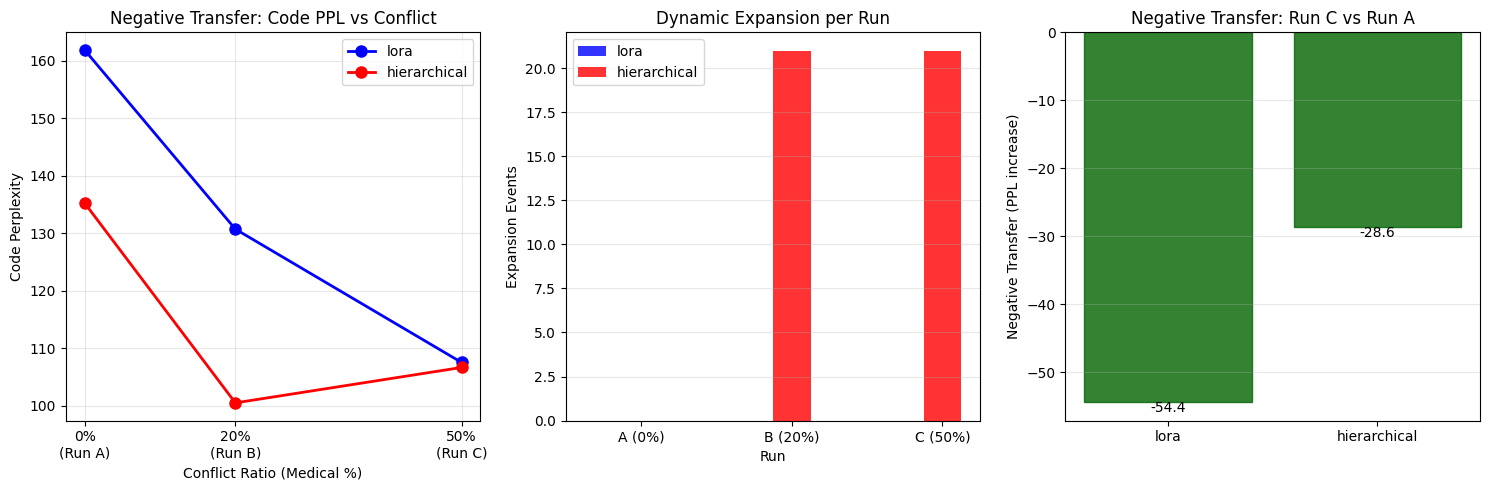

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Plot Comparison — Conflict-Scaling Grid
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {"lora": "blue", "dr_lora": "green", "hierarchical": "red"}
markers = {"A": "o", "B": "s", "C": "^"}

# Plot 1: Code PPL vs Conflict Ratio (negative transfer visualization)
ax = axes[0]
for method_name in COMPARISON_CFG["methods"]:
    conflict_ratios = []
    ppls = []
    for run_label in ["A", "B", "C"]:
        run_key = f"{method_name}_{run_label}"
        if run_key in all_results:
            conflict_ratios.append(all_results[run_key]["conflict_ratio"])
            ppls.append(all_results[run_key]["final_ppl"])
    if conflict_ratios:
        ax.plot(conflict_ratios, ppls, 'o-', label=method_name, color=colors[method_name], linewidth=2, markersize=8)
ax.set_xlabel("Conflict Ratio (Medical %)")
ax.set_ylabel("Code Perplexity")
ax.set_title("Negative Transfer: Code PPL vs Conflict")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks([0.0, 0.2, 0.5])
ax.set_xticklabels(["0%\n(Run A)", "20%\n(Run B)", "50%\n(Run C)"])

# Plot 2: Expansion events across runs
ax = axes[1]
x_positions = {"A": 0, "B": 1, "C": 2}
bar_width = 0.25
for i, method_name in enumerate(COMPARISON_CFG["methods"]):
    expansions = []
    for run_label in ["A", "B", "C"]:
        run_key = f"{method_name}_{run_label}"
        if run_key in all_results:
            expansions.append(all_results[run_key]["n_expansions"])
        else:
            expansions.append(0)
    positions = [x + i * bar_width for x in x_positions.values()]
    ax.bar(positions, expansions, bar_width, label=method_name, color=colors[method_name], alpha=0.8)
ax.set_xlabel("Run")
ax.set_ylabel("Expansion Events")
ax.set_title("Dynamic Expansion per Run")
ax.set_xticks([x + bar_width for x in x_positions.values()])
ax.set_xticklabels(["A (0%)", "B (20%)", "C (50%)"])
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Plot 3: Negative transfer bar chart (Run C - Run A)
ax = axes[2]
methods = COMPARISON_CFG["methods"]
neg_transfers = []
for method_name in methods:
    run_a_key = f"{method_name}_A"
    run_c_key = f"{method_name}_C"
    if run_a_key in all_results and run_c_key in all_results:
        nt = all_results[run_c_key]["final_ppl"] - all_results[run_a_key]["final_ppl"]
    else:
        nt = 0
    neg_transfers.append(nt)

bars = ax.bar(methods, neg_transfers, color=[colors[m] for m in methods], alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel("Negative Transfer (PPL increase)")
ax.set_title("Negative Transfer: Run C vs Run A")
ax.grid(alpha=0.3, axis='y')

# Color bars: red for positive (bad), green for negative (good)
for bar, nt in zip(bars, neg_transfers):
    if nt > 0:
        bar.set_color('darkred')
    else:
        bar.set_color('darkgreen')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{nt:+.1f}', ha='center', va='bottom' if nt >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, 'conflict_scaling_results.png'), dpi=150)
plt.show()

## Section 7 — HumanEval Evaluation

In [ ]:
!pip install human_eval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.6 MB/s eta 0:00:00


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# generate_completion — defined here so debug cells 27-30 can use it
# ═══════════════════════════════════════════════════════════════════════════════

def generate_completion(model, tokenizer, prompt, max_new_tokens=256):
    model.eval()
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    completion = tokenizer.decode(outputs[0], skip_special_tokens=True)
    new_text = completion[len(prompt):]
    for stop in ['\ndef ', '\nclass ', '\n# ', '\nif __name__']:
        if stop in new_text:
            new_text = new_text[:new_text.index(stop)]
    return new_text


print('generate_completion defined.')

In [ ]:
# Add this debug cell BEFORE running HumanEval
run_key = "lora_C"
adapter_state = all_results[run_key]["adapter_state"]
print(f"Total adapter keys: {len(adapter_state)}")
print("Sample keys:")
for k in list(adapter_state.keys())[:10]:
    print(f"  {k}")

Total adapter keys: 128
Sample keys:
  model.layers.8.mlp.experts.base_loras.0.A
  model.layers.8.mlp.experts.base_loras.0.B
  model.layers.8.mlp.experts.base_loras.1.A
  model.layers.8.mlp.experts.base_loras.1.B
  model.layers.8.mlp.experts.base_loras.2.A
  model.layers.8.mlp.experts.base_loras.2.B
  model.layers.8.mlp.experts.base_loras.3.A
  model.layers.8.mlp.experts.base_loras.3.B
  model.layers.8.mlp.experts.base_loras.4.A
  model.layers.8.mlp.experts.base_loras.4.B


In [ ]:
# ── Guard: only run after Cell 32 (HumanEval) which defines model_eval ──
if 'model_eval' not in dir():
    print('Skipping — run Cell 32 (HumanEval setup) first to define model_eval')
else:
    # Quick sanity check — see what the model is actually generating
    test_prompts = [
        'def add(a, b):\n    """Add two numbers."""\n    return',
        'def has_close_elements(numbers: List[float], threshold: float) -> bool:\n    """ Check if in given list of numbers, are any two numbers closer to each other than\n    given threshold.\n    """\n',
    ]
    
    wrapper, _, _ = setup_method(model_eval, "hierarchical", COMPARISON_CFG)
    # load weights...
    
    for p in test_prompts:
        raw = generate_completion(model_eval, tokenizer, p, max_new_tokens=100)
        print(f"PROMPT: {p[:50]}...")
        print(f"RAW COMPLETION: repr={repr(raw)}")
        print(f"LENGTH: {len(raw)}")
        print()

PROMPT: def add(a, b):
    """Add two numbers."""
    retu...
RAW COMPLETION: repr=' a + b\n'
LENGTH: 7

PROMPT: def has_close_elements(numbers: List[float], thres...
RAW COMPLETION: repr='    for i in range(len(numbers) - 1):\n        if numbers[i] - numbers[i + 1] < threshold:\n            return True\n    return False\n\n'
LENGTH: 132



In [ ]:
# ── Guard: only run after Cell 32 (HumanEval) which defines model_eval ──
if 'model_eval' not in dir():
    print('Skipping — run Cell 32 (HumanEval setup) first to define model_eval')
else:
    # Check if B matrices are all zero (means weights never loaded)
    adapter_state = all_results["hierarchical_C"]["adapter_state"]
    
    b_keys = [k for k in adapter_state.keys() if k.endswith(".B")]
    print(f"Checking {len(b_keys)} B matrices from saved adapter_state:")
    for k in b_keys[:5]:
        val = adapter_state[k]
        print(f"  {k}: max={val.abs().max().item():.6f}, mean={val.abs().mean().item():.6f}")
    
    print()
    # Now check what's actually in the model after loading
    wrapper, _, _ = setup_method(model_eval, "hierarchical", COMPARISON_CFG)
    model_eval.load_state_dict(adapter_state, strict=False)
    
    print("Checking B matrices IN MODEL after load:")
    model_params = dict(model_eval.named_parameters())
    for k in b_keys[:5]:
        if k in model_params:
            val = model_params[k]
            print(f"  {k}: max={val.abs().max().item():.6f}, mean={val.abs().mean().item():.6f}")
        else:
            print(f"  {k}: NOT FOUND in model")

Checking 64 B matrices from saved adapter_state:
  model.layers.8.mlp.experts.base_loras.0.B: max=0.006897, mean=0.001900
  model.layers.8.mlp.experts.base_loras.1.B: max=0.007660, mean=0.002274
  model.layers.8.mlp.experts.base_loras.2.B: max=0.006104, mean=0.001862
  model.layers.8.mlp.experts.base_loras.3.B: max=0.006470, mean=0.001892
  model.layers.8.mlp.experts.base_loras.4.B: max=0.007690, mean=0.002213

Checking B matrices IN MODEL after load:
  model.layers.8.mlp.experts.base_loras.0.B: max=0.006897, mean=0.001900
  model.layers.8.mlp.experts.base_loras.1.B: max=0.007660, mean=0.002274
  model.layers.8.mlp.experts.base_loras.2.B: max=0.006104, mean=0.001862
  model.layers.8.mlp.experts.base_loras.3.B: max=0.006470, mean=0.001892
  model.layers.8.mlp.experts.base_loras.4.B: max=0.007690, mean=0.002213


In [ ]:
print("Training config:")
print(f"  lr:           {COMPARISON_CFG['lr']}")
print(f"  n_steps:      {COMPARISON_CFG['n_steps']}")
print(f"  target_layer: {COMPARISON_CFG['target_layer']}")
print(f"  base_rank:    {COMPARISON_CFG['base_rank']}")

# Also check A matrices — if they moved from init, gradient is flowing
a_keys = [k for k in adapter_state.keys() if k.endswith(".A")]
print("\nA matrix norms (should differ from 0.01 init if training worked):")
for k in a_keys[:5]:
    val = adapter_state[k]
    print(f"  {k}: std={val.std().item():.6f} (init was 0.01)")

Training config:
  lr:           2e-05
  n_steps:      3000
  target_layer: 8
  base_rank:    16

A matrix norms (should differ from 0.01 init if training worked):
  model.layers.8.mlp.experts.base_loras.0.A: std=0.010132 (init was 0.01)
  model.layers.8.mlp.experts.base_loras.1.A: std=0.010010 (init was 0.01)
  model.layers.8.mlp.experts.base_loras.2.A: std=0.010132 (init was 0.01)
  model.layers.8.mlp.experts.base_loras.3.A: std=0.010132 (init was 0.01)
  model.layers.8.mlp.experts.base_loras.4.A: std=0.010254 (init was 0.01)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# HumanEval — Evaluate base model + each method's Run C adapter
# ═══════════════════════════════════════════════════════════════════════════════

from human_eval.data import read_problems
from human_eval.evaluation import evaluate_functional_correctness


def run_humaneval(model, tokenizer, label):
    problems = read_problems()
    print(f"\n[{label}] Running HumanEval on {len(problems)} problems...")

    samples = []
    for i, (task_id, problem) in enumerate(problems.items()):
        completion = generate_completion(model, tokenizer, problem['prompt'])
        samples.append({'task_id': task_id, 'completion': completion})
        if (i + 1) % 20 == 0:
            print(f"  Generated {i+1}/{len(problems)}")

    samples_path = os.path.join(SAVE_ROOT, f'humaneval_{label}.jsonl')
    with open(samples_path, 'w') as f:
        for s in samples:
            f.write(json.dumps(s) + '\n')

    results = evaluate_functional_correctness(samples_path)
    pass_at_1 = results['pass@1'] * 100
    print(f"[{label}] Pass@1: {pass_at_1:.2f}%")
    return pass_at_1


humaneval_results = {}

# ── 1. Base model (no adapters) ───────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()

model_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map='auto', trust_remote_code=True
)
model_eval.config.use_cache = True

humaneval_results["base"] = run_humaneval(model_eval, tokenizer, "base")

del model_eval
gc.collect()
torch.cuda.empty_cache()


# ── 2. Each method, Run C adapter ─────────────────────────────────────────────
for method_name in COMPARISON_CFG["methods"]:
    print(method_name)
    run_key = f"{method_name}_C"

    if run_key not in all_results:
        print(f"Skipping {run_key} — not found in all_results")
        continue

    if "adapter_state" not in all_results[run_key]:
        print(f"Skipping {run_key} — no adapter_state saved (re-run training with the fix above)")
        continue

    gc.collect()
    torch.cuda.empty_cache()

    # Fresh base model
    model_eval = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.bfloat16, device_map='auto', trust_remote_code=True
    )
    model_eval.config.use_cache = True

    # Build wrapper first (this attaches adapter modules with fresh weights)
    wrapper, _, _ = setup_method(model_eval, method_name, COMPARISON_CFG)

    # Now load saved weights — they overwrite the fresh init
    adapter_state = all_results[run_key]["adapter_state"]
    missing, unexpected = model_eval.load_state_dict(adapter_state, strict=False)

    # Verify the load actually took effect
    print(f"  Keys in adapter_state: {len(adapter_state)}")
    print(f"  Unexpected (not in model): {len(unexpected)}")
    # Should be 0 unexpected if wrapper attaches at the right paths

    # Spot-check one weight is non-zero
    sample_key = list(adapter_state.keys())[1]  # pick .B key (was zero-init, should be non-zero after training)
    loaded_val = dict(model_eval.named_parameters())[sample_key]
    saved_val = adapter_state[sample_key]
    match = torch.allclose(loaded_val.cpu().float(), saved_val.float())
    print(f"  Weight check ({sample_key}): {'MATCH ✓' if match else 'MISMATCH ✗'}")

    if missing:
        print(f"  Warning: {len(missing)} missing keys (expected for base weights)")
    if unexpected:
        print(f"  Warning: {len(unexpected)} unexpected keys")

    humaneval_results[method_name] = run_humaneval(model_eval, tokenizer, method_name)

    del model_eval, wrapper
    gc.collect()
    torch.cuda.empty_cache()

# ── 3. Summary ────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("HUMANEVAL RESULTS SUMMARY")
print("=" * 50)
for label, score in humaneval_results.items():
    print(f"  {label:<20} Pass@1: {score:.2f}%")

# Save to all_results
all_results["humaneval"] = humaneval_results

Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]


[base] Running HumanEval on 164 problems...
  Generated 20/164
  Generated 40/164
  Generated 60/164
  Generated 80/164
  Generated 100/164
  Generated 120/164
  Generated 140/164
  Generated 160/164
Reading samples...


164it [00:00, 1315.90it/s]


Running test suites...


100%|██████████| 164/164 [00:08<00:00, 18.51it/s]


...

100%|██████████| 164/164 [00:00<00:00, 70140.29it/s]


[lora] Pass@1: 0.00%
hierarchical


Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

  Keys in adapter_state: 128
  Unexpected (not in model): 0
  Weight check (model.layers.8.mlp.experts.base_loras.0.B): MATCH ✓

[hierarchical] Running HumanEval on 164 problems...
  Generated 20/164
  Generated 40/164


KeyboardInterrupt: 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Save Final Summary — Thesis Format
# ═══════════════════════════════════════════════════════════════════════════════

summary = {
    "model": MODEL_ID,
    "config": COMPARISON_CFG,
    "results": {},
    "negative_transfer": {},
}

# Organize results by method and run
for run_key, r in all_results.items():
    if run_key == "humaneval":
        continue
    method = r["method"]
    run_label = r["run"]

    if method not in summary["results"]:
        summary["results"][method] = {}

    summary["results"][method][run_label] = {
        "conflict_ratio": r["conflict_ratio"],
        "final_code_ppl": r["final_ppl"],
        "n_expansions": r["n_expansions"],
    }

    # Compute negative transfer for non-baseline runs
    if run_label != "A" and method in baseline_ppl_code:
        neg_transfer = r["final_ppl"] - baseline_ppl_code[method]
        if method not in summary["negative_transfer"]:
            summary["negative_transfer"][method] = {}
        summary["negative_transfer"][method][run_label] = neg_transfer

if "humaneval" in all_results:
    summary["humaneval"] = all_results["humaneval"]

summary_path = os.path.join(SAVE_ROOT, 'experiment_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 80)
print("THESIS EXPERIMENT COMPLETE")
print("=" * 80)
print(f"\nSummary saved to: {summary_path}")

print("\n── Results by Method ──")
for method in COMPARISON_CFG["methods"]:
    if method in summary["results"]:
        print(f"\n{method.upper()}:")
        for run_label in ["A", "B", "C"]:
            if run_label in summary["results"][method]:
                r = summary["results"][method][run_label]
                nt = summary["negative_transfer"].get(method, {}).get(run_label, 0)
                nt_str = f"NT: {nt:+.2f}" if run_label != "A" else "baseline"
                print(f"  Run {run_label} ({r['conflict_ratio']:.0%}): PPL {r['final_code_ppl']:.2f}, {r['n_expansions']} expansions, {nt_str}")